##### Load Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import json
from sklearn.model_selection import train_test_split

##### Load and Add Target Columns
- target map is exported as a json file
- targets are added here since they are based on file names
- target column is added in the dataframe to prevent duplicate csv's (without targets in mixed_ratio folder, with target in RF folder)
- target label encoding happens in this cell as well since RF can only use numerical values

In [2]:
# Build two separate labeled dataframes -- single_df and mixed_ratio_df -- so the
# row counts and per-group spectra plots below never mix the two experiment types.

# dictionary for value insertion for target column
# Keys are matched against file names, so keep these specific enough to avoid overlap.
targets = {
    "PAO1": "0:1 | Staph : PAO",
    "STAPH": "1:0 | Staph : PAO",
    "1-9": "1:9 | Staph : PAO",
    "3-7": "3:7 | Staph : PAO",
    "5-5": "5:5 | Staph : PAO",
    "7-3": "7:3 | Staph : PAO",
    "9-1": "9:1 | Staph : PAO"
}

def find_csv_files(data_path):
    if not os.path.isdir(data_path):
        raise FileNotFoundError(f"Data folder not found: {data_path}")

    csv_files = []
    for root, dirs, files in os.walk(data_path):
        dirs[:] = sorted(d for d in dirs if not d.startswith("."))
        for file_name in sorted(files):
            if file_name.endswith(".csv"):
                csv_files.append(os.path.join(root, file_name))

    return sorted(csv_files)

def read_all_csvs_to_df(data_path):
    dataframes = []

    file_list = find_csv_files(data_path)
    if not file_list:
        raise ValueError(f"No CSV files found in: {data_path}")

    for i, file_path in enumerate(file_list):
        file_name = os.path.basename(file_path)
        df = pd.read_csv(file_path, header=None)

        # The first row of every CSV is the shared wavenumber axis; keep it only from
        # the first file so the combined frame has a single wavenumber row on top.
        if i != 0:
            df = df.iloc[1:].reset_index(drop=True)

        # adding the target column values based on the target dictionary above
        target_value = next((value for key, value in targets.items() if key.lower() in file_name.lower()), None)

        if target_value is None:
            raise ValueError(f"No target mapping found for file: {file_name}")

        labeled_df = df.copy()
        labeled_df["target"] = target_value
        dataframes.append(labeled_df)

    # Some files have a different number of feature columns. Keep only the columns
    # shared by all files so every spectrum stays aligned on the same wavenumber axis.
    combined_df = pd.concat(dataframes, ignore_index=True, join="inner").copy()

    return combined_df


# The single-species and mixed-ratio spectra live in separate folders; read each
# into its own dataframe so counts/splits stay accurate per experiment type.
single_df = read_all_csvs_to_df(os.path.join("data", "single"))
mixed_ratio_df = read_all_csvs_to_df(os.path.join("data", "mixed_ratio"))

print("single_df shape (incl. wavenumber row):", single_df.shape)
print("mixed_ratio_df shape (incl. wavenumber row):", mixed_ratio_df.shape)

single_df shape (incl. wavenumber row): (9759, 389)
mixed_ratio_df shape (incl. wavenumber row): (61755, 389)


##### Label Data and Drop Target Column
- feature map is exported as a json file
- target column needs to be dropped for RF training since it's already been encoded
- target couldn't be dropped earlier because the logic needed that column for labelling

In [3]:
def label_data(dataframe):
    """Separate the wavenumber header row from the spectra, keeping the string label.

    Returns:
        clean_df: one row per measurement; feature columns numbered 1..N plus the
                  'target' label column (kept so we can group/count by species).
        wavenumbers: the wavenumber for each feature column (the plot x-axis).
    """
    target_idx = dataframe.columns.get_loc("target")
    feature_cols = dataframe.columns[:target_idx]

    # Row 0 holds the wavenumber for each feature column.
    wavenumbers = dataframe.iloc[0, :target_idx].to_numpy(dtype=float)
    feature_labels = list(range(1, len(feature_cols) + 1))

    # Drop the wavenumber row so only real measurements remain, then renumber columns.
    clean_df = dataframe.iloc[1:].reset_index(drop=True).copy()
    clean_df = clean_df.rename(columns=dict(zip(feature_cols, feature_labels)))
    clean_df[feature_labels] = clean_df[feature_labels].astype(float)

    return clean_df, wavenumbers


# Clean both frames; each keeps its own wavenumber axis so the single and mixed
# datasets never have to share the same number of feature columns.
single_df, single_wavenumbers = label_data(single_df)
mixed_ratio_df, mixed_ratio_wavenumbers = label_data(mixed_ratio_df)

print("single_df:", single_df.shape, "| labels:", sorted(single_df["target"].unique()))
print("mixed_ratio_df:", mixed_ratio_df.shape, "| labels:", sorted(mixed_ratio_df["target"].unique()))

single_df: (9758, 389) | labels: ['0:1 | Staph : PAO', '1:0 | Staph : PAO']
mixed_ratio_df: (61754, 389) | labels: ['1:9 | Staph : PAO', '3:7 | Staph : PAO', '5:5 | Staph : PAO', '7:3 | Staph : PAO', '9:1 | Staph : PAO']


##### Averaged Spectra for Each Single Species (Mean)

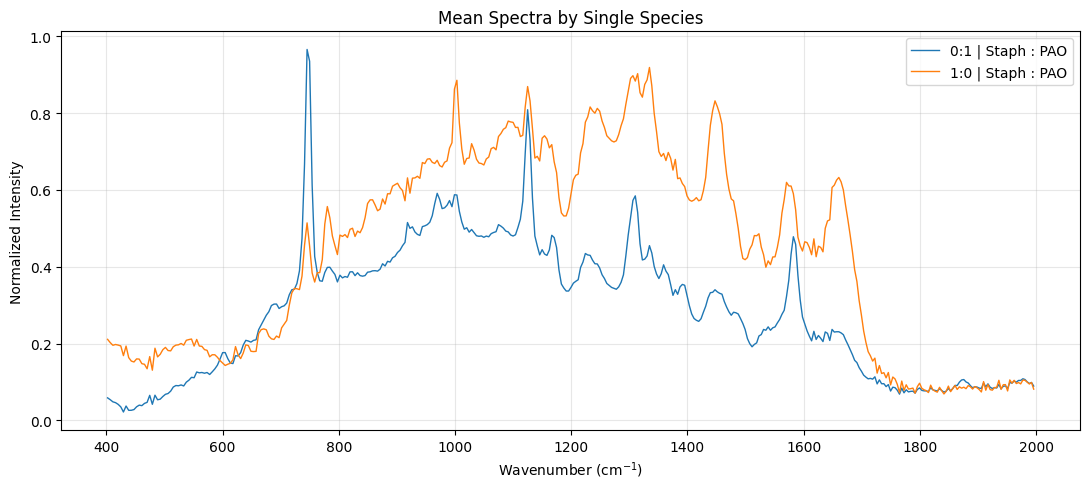

In [4]:
# Mean spectrum per single-species label (normalized intensity vs wavenumber).
# single_df only holds the single species, so this plots PAO1 (0:1) and Staph (1:0).
feature_cols = [c for c in single_df.columns if c != "target"]
mean_spectra = single_df.groupby("target")[feature_cols].mean()

plt.figure(figsize=(11, 5))
for label, row in mean_spectra.iterrows():
    plt.plot(single_wavenumbers, row.to_numpy(), label=label, linewidth=1)
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Normalized Intensity")
plt.title("Mean Spectra by Single Species")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Averaged Spectra for Each Mixed Ratio Species (Mean)

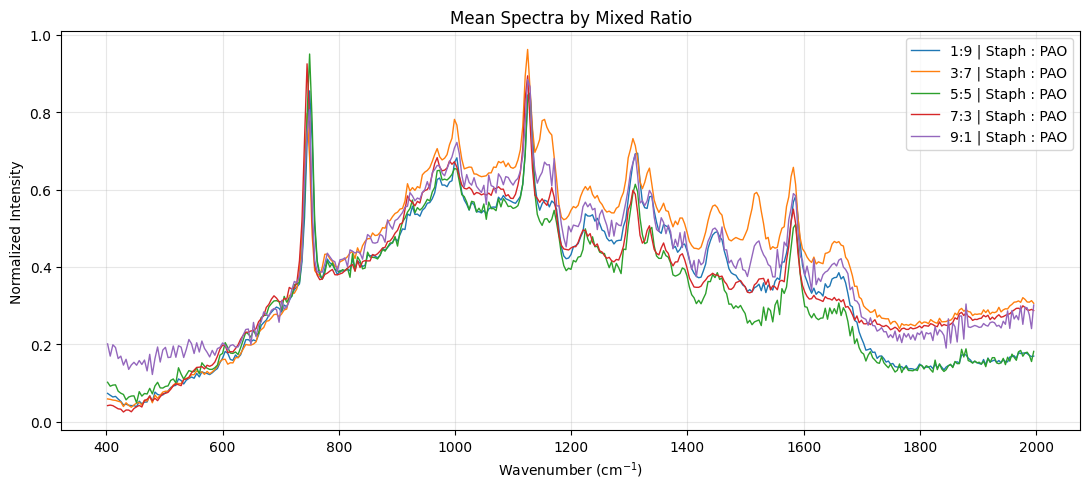

In [5]:
# Mean spectrum per mixed-ratio label (normalized intensity vs wavenumber).
feature_cols = [c for c in mixed_ratio_df.columns if c != "target"]
mean_spectra = mixed_ratio_df.groupby("target")[feature_cols].mean()

plt.figure(figsize=(11, 5))
for label, row in mean_spectra.iterrows():
    plt.plot(mixed_ratio_wavenumbers, row.to_numpy(), label=label, linewidth=1)
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Normalized Intensity")
plt.title("Mean Spectra by Mixed Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Averaged Spectra for Each Single Species (Median)

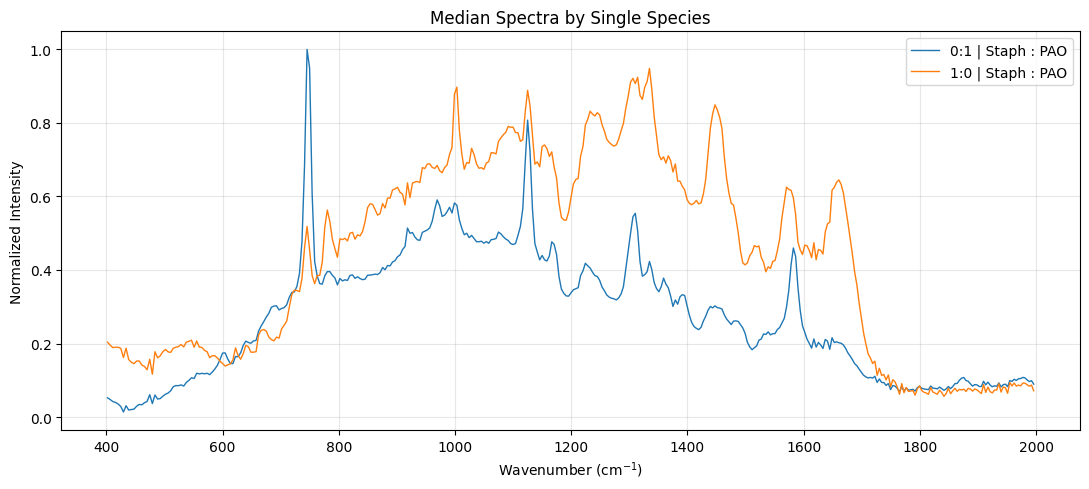

In [6]:
# Median spectrum per single-species label (normalized intensity vs wavenumber).
feature_cols = [c for c in single_df.columns if c != "target"]
median_spectra = single_df.groupby("target")[feature_cols].median()

plt.figure(figsize=(11, 5))
for label, row in median_spectra.iterrows():
    plt.plot(single_wavenumbers, row.to_numpy(), label=label, linewidth=1)
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Normalized Intensity")
plt.title("Median Spectra by Single Species")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Averaged Spectra for Each Mixed Ratio Species (Median)

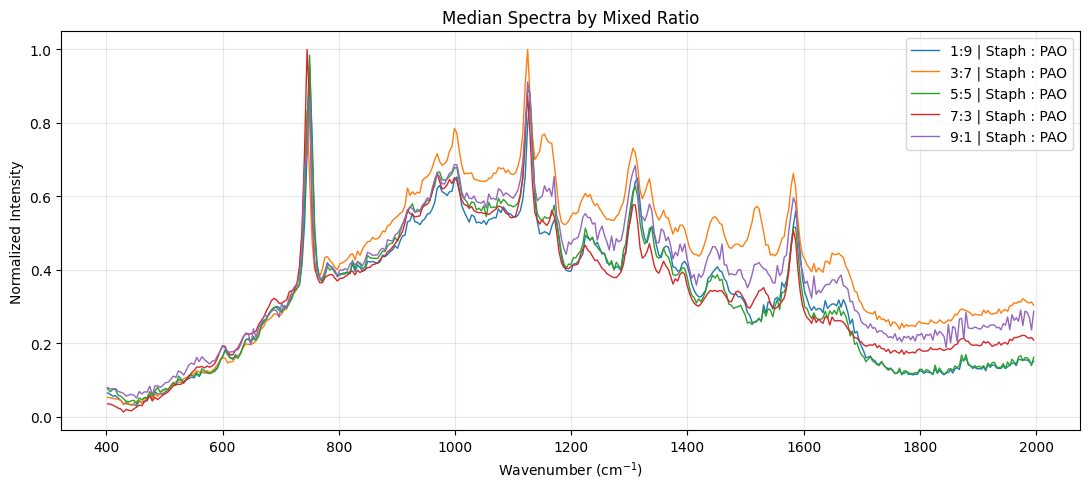

In [7]:
# Median spectrum per mixed-ratio label (normalized intensity vs wavenumber).
feature_cols = [c for c in mixed_ratio_df.columns if c != "target"]
median_spectra = mixed_ratio_df.groupby("target")[feature_cols].median()

plt.figure(figsize=(11, 5))
for label, row in median_spectra.iterrows():
    plt.plot(mixed_ratio_wavenumbers, row.to_numpy(), label=label, linewidth=1)
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Normalized Intensity")
plt.title("Median Spectra by Mixed Ratio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Counts for Rows in Mixed Ratios

In [8]:
# Row count for each mixed-ratio species label.
mixed_counts = mixed_ratio_df["target"].value_counts().sort_index()
print("Row counts per mixed-ratio label:")
print(mixed_counts.to_string())
print("\nTotal mixed-ratio rows:", len(mixed_ratio_df))

Row counts per mixed-ratio label:
target
1:9 | Staph : PAO    19915
3:7 | Staph : PAO     9636
5:5 | Staph : PAO    10323
7:3 | Staph : PAO     9772
9:1 | Staph : PAO    12108

Total mixed-ratio rows: 61754


##### Train Test Split Counts for Mixed Ratios

In [9]:
# Stratified 80/20 train-test split (random_state=42) on the mixed-ratio data;
# report total, 80% train, and 20% test row counts for each label.
mixed_train_df, mixed_test_df = train_test_split(
    mixed_ratio_df,
    test_size=0.2,
    random_state=42,
    stratify=mixed_ratio_df["target"],
)

mixed_split_counts = pd.DataFrame({
    "total": mixed_ratio_df["target"].value_counts(),
    "train (80%)": mixed_train_df["target"].value_counts(),
    "test (20%)": mixed_test_df["target"].value_counts(),
}).fillna(0).astype(int).sort_index()

print("Mixed-ratio train/test split counts (random_state=42):")
print(mixed_split_counts.to_string())
print(
    "\nTotals -> all:", len(mixed_ratio_df),
    "| train:", len(mixed_train_df),
    "| test:", len(mixed_test_df),
)

Mixed-ratio train/test split counts (random_state=42):
                   total  train (80%)  test (20%)
target                                           
1:9 | Staph : PAO  19915        15932        3983
3:7 | Staph : PAO   9636         7709        1927
5:5 | Staph : PAO  10323         8258        2065
7:3 | Staph : PAO   9772         7818        1954
9:1 | Staph : PAO  12108         9686        2422

Totals -> all: 61754 | train: 49403 | test: 12351


##### Counts for Rows in Single Species

In [10]:
# Row count for each single-species label (0:1 = PAO1, 1:0 = Staph).
single_counts = single_df["target"].value_counts().sort_index()
print("Row counts per single-species label:")
print(single_counts.to_string())
print("\nTotal single-species rows:", len(single_df))

Row counts per single-species label:
target
0:1 | Staph : PAO    4363
1:0 | Staph : PAO    5395

Total single-species rows: 9758


##### Train Test Split Counts for Single Species Ratios

In [11]:
# Stratified 80/20 train-test split (random_state=42) on the single-species data;
# report total, 80% train, and 20% test row counts for each label.
single_train_df, single_test_df = train_test_split(
    single_df,
    test_size=0.2,
    random_state=42,
    stratify=single_df["target"],
)

single_split_counts = pd.DataFrame({
    "total": single_df["target"].value_counts(),
    "train (80%)": single_train_df["target"].value_counts(),
    "test (20%)": single_test_df["target"].value_counts(),
}).fillna(0).astype(int).sort_index()

print("Single-species train/test split counts (random_state=42):")
print(single_split_counts.to_string())
print(
    "\nTotals -> all:", len(single_df),
    "| train:", len(single_train_df),
    "| test:", len(single_test_df),
)

Single-species train/test split counts (random_state=42):
                   total  train (80%)  test (20%)
target                                           
0:1 | Staph : PAO   4363         3490         873
1:0 | Staph : PAO   5395         4316        1079

Totals -> all: 9758 | train: 7806 | test: 1952
